In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/yangsangtai/tiny-genimage/imagenet_ai_0424_wukong/val/nature/ILSVRC2012_val_00010238.JPEG
/kaggle/input/datasets/yangsangtai/tiny-genimage/imagenet_ai_0424_wukong/val/nature/ILSVRC2012_val_00037999.JPEG
/kaggle/input/datasets/yangsangtai/tiny-genimage/imagenet_ai_0424_wukong/val/nature/ILSVRC2012_val_00045503.JPEG
/kaggle/input/datasets/yangsangtai/tiny-genimage/imagenet_ai_0424_wukong/val/nature/ILSVRC2012_val_00041823.JPEG
/kaggle/input/datasets/yangsangtai/tiny-genimage/imagenet_ai_0424_wukong/val/nature/ILSVRC2012_val_00022738.JPEG
/kaggle/input/datasets/yangsangtai/tiny-genimage/imagenet_ai_0424_wukong/val/nature/ILSVRC2012_val_00049064.JPEG
/kaggle/input/datasets/yangsangtai/tiny-genimage/imagenet_ai_0424_wukong/val/nature/ILSVRC2012_val_00015489.JPEG
/kaggle/input/datasets/yangsangtai/tiny-genimage/imagenet_ai_0424_wukong/val/nature/ILSVRC2012_val_00022467.JPEG
/kaggle/input/datasets/yangsangtai/tiny-genimage/imagenet_ai_0424_wukong/val/nature/ILSVRC2012_v

In [2]:
!pip install -q torch torchvision scikit-learn matplotlib seaborn pandas

import os
import time
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, ConcatDataset, random_split, Dataset
from torchvision import datasets, transforms, models

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)
from IPython.display import FileLink, display

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Torch version: 2.10.0+cu128
CUDA available: True


In [3]:
DATASET_ROOT = "/kaggle/input/datasets/yangsangtai/tiny-genimage/imagenet_ai_0424_wukong"

TRAIN_DIR = os.path.join(DATASET_ROOT, "train")
VAL_DIR = os.path.join(DATASET_ROOT, "val")

CONFIG = {
    "seed": 42,
    "image_size": 456,
    "batch_size": 8,            
    "accum_steps": 2,           
    "num_workers": 2,
    "num_epochs": 100,          
    "learning_rate": 1e-4,
}

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(CONFIG["seed"])
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


In [4]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_test_transforms = transforms.Compose([
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Load without transforms first so we can cleanly merge and split
raw_train = datasets.ImageFolder(TRAIN_DIR)
raw_val = datasets.ImageFolder(VAL_DIR)
full_dataset = ConcatDataset([raw_train, raw_val])

CLASS_TO_IDX = raw_train.class_to_idx
IDX_TO_CLASS = {v: k for k, v in CLASS_TO_IDX.items()}

# split lengths (70% Train, 15% Val, 15% Test)
total_len = len(full_dataset)
train_len = int(0.7 * total_len)
val_len = int(0.15 * total_len)
test_len = total_len - train_len - val_len

train_subset, val_subset, test_subset = random_split(
    full_dataset, 
    [train_len, val_len, test_len],
    generator=torch.Generator().manual_seed(CONFIG["seed"])
)

# Custom wrapper to apply transforms dynamically to subsets
class TransformWrapper(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)

train_dataset = TransformWrapper(train_subset, transform=train_transforms)
val_dataset = TransformWrapper(val_subset, transform=val_test_transforms)
test_dataset = TransformWrapper(test_subset, transform=val_test_transforms)

print(f"Total images: {total_len}")
print(f"Train images: {len(train_dataset)} | Val images: {len(val_dataset)} | Test images: {len(test_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"], shuffle=True,
                           num_workers=CONFIG["num_workers"], pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=CONFIG["batch_size"], shuffle=False,
                         num_workers=CONFIG["num_workers"], pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=CONFIG["batch_size"], shuffle=False,
                         num_workers=CONFIG["num_workers"], pin_memory=True)

Total images: 5000
Train images: 3500 | Val images: 750 | Test images: 750


In [5]:
def build_model(num_classes=2):
    model = models.efficientnet_b5(weights=None)
    
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    
    return model

model = build_model(num_classes=2).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=CONFIG["learning_rate"])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=1)

num_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model ready on {DEVICE}. Trainable parameters: {num_trainable:,}")

Model ready on cuda. Trainable parameters: 28,344,882


Epoch 1/100 | train_loss=0.6362 train_acc=0.6591 | val_loss=0.6964 val_acc=0.5080 | 194.2s [*Saved Best Checkpoint]
Epoch 2/100 | train_loss=0.5535 train_acc=0.7177 | val_loss=1.1022 val_acc=0.7280 | 166.7s [*Saved Best Checkpoint]
Epoch 3/100 | train_loss=0.4810 train_acc=0.7823 | val_loss=0.8572 val_acc=0.7493 | 166.1s [*Saved Best Checkpoint]
Epoch 4/100 | train_loss=0.4415 train_acc=0.8080 | val_loss=0.4989 val_acc=0.7920 | 166.3s [*Saved Best Checkpoint]
Epoch 5/100 | train_loss=0.4160 train_acc=0.8154 | val_loss=0.4585 val_acc=0.8280 | 165.4s [*Saved Best Checkpoint]
Epoch 6/100 | train_loss=0.4075 train_acc=0.8220 | val_loss=0.4722 val_acc=0.8493 | 165.2s [*Saved Best Checkpoint]
Epoch 7/100 | train_loss=0.3950 train_acc=0.8251 | val_loss=0.4777 val_acc=0.8360 | 164.8s
Epoch 8/100 | train_loss=0.3870 train_acc=0.8289 | val_loss=0.4296 val_acc=0.8520 | 166.3s [*Saved Best Checkpoint]
Epoch 9/100 | train_loss=0.3760 train_acc=0.8371 | val_loss=0.4497 val_acc=0.8187 | 165.2s
Epoch 

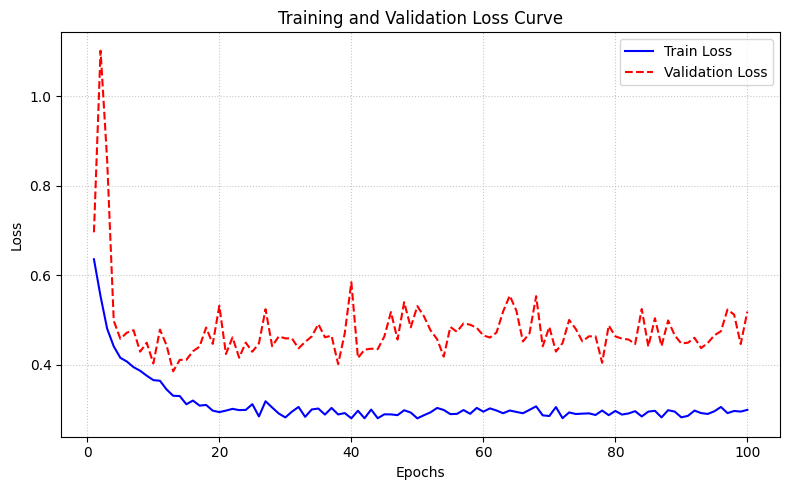

In [6]:
 scaler = torch.amp.GradScaler('cuda')

def run_epoch(model, loader, criterion, optimizer=None, accum_steps=1):
    is_training = optimizer is not None
    model.train() if is_training else model.eval()

    total_loss = 0.0
    all_preds, all_labels = [], []

    if is_training:
        optimizer.zero_grad()

    torch.set_grad_enabled(is_training)
    for step, (images, labels) in enumerate(loader):
        images, labels = images.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)

        with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
            outputs = model(images)
            loss = criterion(outputs, labels)
            if is_training:
                loss = loss / accum_steps

        if is_training:
            scaler.scale(loss).backward()
            if (step + 1) % accum_steps == 0 or (step + 1) == len(loader):
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()

        total_loss += loss.item() * accum_steps * images.size(0)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
    torch.set_grad_enabled(True)

    avg_loss = total_loss / len(loader.dataset)
    accuracy = accuracy_score(all_labels, all_preds)
    return avg_loss, accuracy

best_val_acc = 0.0
best_val_loss = float('inf')
CHECKPOINT_PATH = "/kaggle/working/best_checkpoint.pth"

# Track history for plotting
history_train_loss = []
history_val_loss = []

for epoch in range(1, CONFIG["num_epochs"] + 1):
    start = time.time()
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer, accum_steps=CONFIG["accum_steps"])
    val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer=None)
    scheduler.step(val_loss)
    
    # Store metrics for curves
    history_train_loss.append(train_loss)
    history_val_loss.append(val_loss)

    # Checkpoint logic: highest accuracy OR lower loss
    saved = False
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        saved = True
    elif val_loss < best_val_loss:
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        saved = True

     
    if val_loss < best_val_loss:
        best_val_loss = val_loss

    elapsed = time.time() - start
    chkpt_msg = " [*Saved Best Checkpoint]" if saved else ""
    print(f"Epoch {epoch}/{CONFIG['num_epochs']} "
          f"| train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
          f"| val_loss={val_loss:.4f} val_acc={val_acc:.4f} "
          f"| {elapsed:.1f}s{chkpt_msg}")

 
model.load_state_dict(torch.load(CHECKPOINT_PATH))
print(f"\nTraining completed. Loaded best checkpoint for evaluation.")

# Generate Loss Curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, CONFIG["num_epochs"] + 1), history_train_loss, label='Train Loss', color='blue')
plt.plot(range(1, CONFIG["num_epochs"] + 1), history_val_loss, label='Validation Loss', color='red', linestyle='--')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curve')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

===== Classification Report (Test Set) =====
              precision    recall  f1-score   support

          ai       0.92      0.79      0.85       370
      nature       0.82      0.94      0.88       380

    accuracy                           0.87       750
   macro avg       0.87      0.86      0.86       750
weighted avg       0.87      0.87      0.86       750



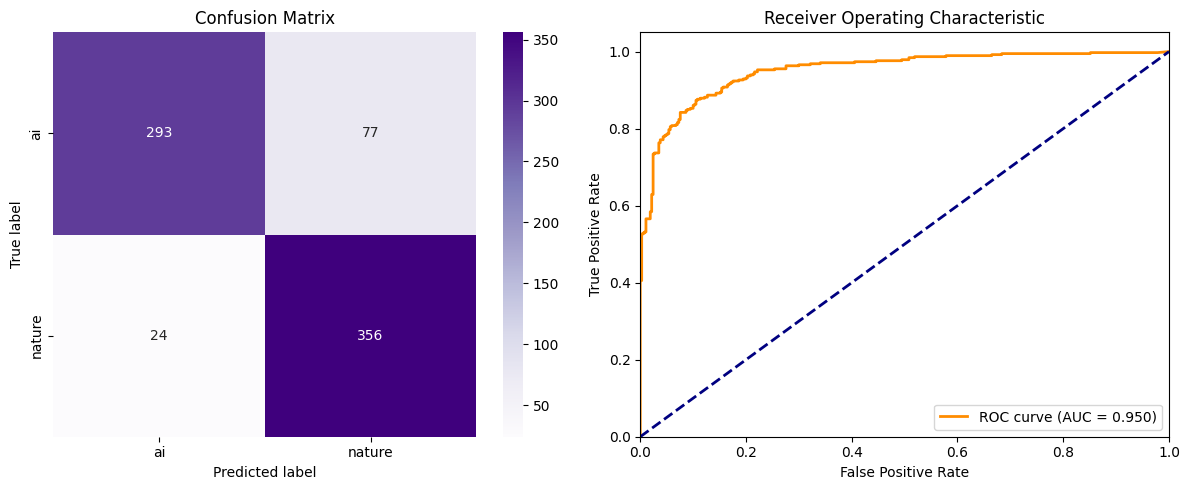

In [7]:
model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        
        # Probabilities for class 1 (nature) used for ROC curve
        probs = torch.softmax(outputs, dim=1)[:, 1].cpu().tolist() 
        preds = outputs.argmax(dim=1).cpu().tolist()
        
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(labels.tolist())

# 1. Classification Report
print("===== Classification Report (Test Set) =====")
print(classification_report(all_labels, all_preds, target_names=[IDX_TO_CLASS[0], IDX_TO_CLASS[1]]))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 2. Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=[IDX_TO_CLASS[0], IDX_TO_CLASS[1]],
            yticklabels=[IDX_TO_CLASS[0], IDX_TO_CLASS[1]], ax=axes[0])
axes[0].set_xlabel("Predicted label")
axes[0].set_ylabel("True label")
axes[0].set_title("Confusion Matrix")

# 3. ROC Curve
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Receiver Operating Characteristic')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

In [8]:
output_dir = "/kaggle/working/results"
os.makedirs(output_dir, exist_ok=True)

acc = accuracy_score(all_labels, all_preds)
pos_lbl = CLASS_TO_IDX.get("ai", 0) 
precision, recall, f1, _ = precision_recall_fscore_support(
    all_labels, all_preds, average="binary", pos_label=pos_lbl
)

results_row = {
    "dataset": "tiny_genimage_wukong",
    "model": "efficientnet_b5",
    "num_epochs": CONFIG["num_epochs"],
    "train_images": len(train_dataset),
    "test_images": len(test_dataset),
    "test_accuracy": round(acc, 4),
    "test_precision": round(precision, 4),
    "test_recall": round(recall, 4),
    "test_f1_score": round(f1, 4),
    "test_auc": round(roc_auc, 4)
}

results_df = pd.DataFrame([results_row])
print(results_df)

RESULTS_CSV_PATH = os.path.join(output_dir, "test_results.csv")
results_df.to_csv(RESULTS_CSV_PATH, index=False)

FINAL_MODEL_PATH = os.path.join(output_dir, "best_model.pth")
import shutil
shutil.copy(CHECKPOINT_PATH, FINAL_MODEL_PATH)

print("\n===== Output Files Saved =====")
print(f"Results table: {RESULTS_CSV_PATH}[cite: 1]")
print(f"Model weights: {FINAL_MODEL_PATH}[cite: 1]")

print("\n===== Download Links =====")
display(FileLink(RESULTS_CSV_PATH))
display(FileLink(FINAL_MODEL_PATH))

                dataset            model  num_epochs  train_images  \
0  tiny_genimage_wukong  efficientnet_b5         100          3500   

   test_images  test_accuracy  test_precision  test_recall  test_f1_score  \
0          750         0.8653          0.9243       0.7919          0.853   

   test_auc  
0    0.9503  

===== Output Files Saved =====
Results table: /kaggle/working/results/test_results.csv[cite: 1]
Model weights: /kaggle/working/results/best_model.pth[cite: 1]

===== Download Links =====


/kaggle/working/results/test_results.csv

/kaggle/working/results/best_model.pth